(7, 7, 3)
(7, 7, 3)
(7, 7, 3)


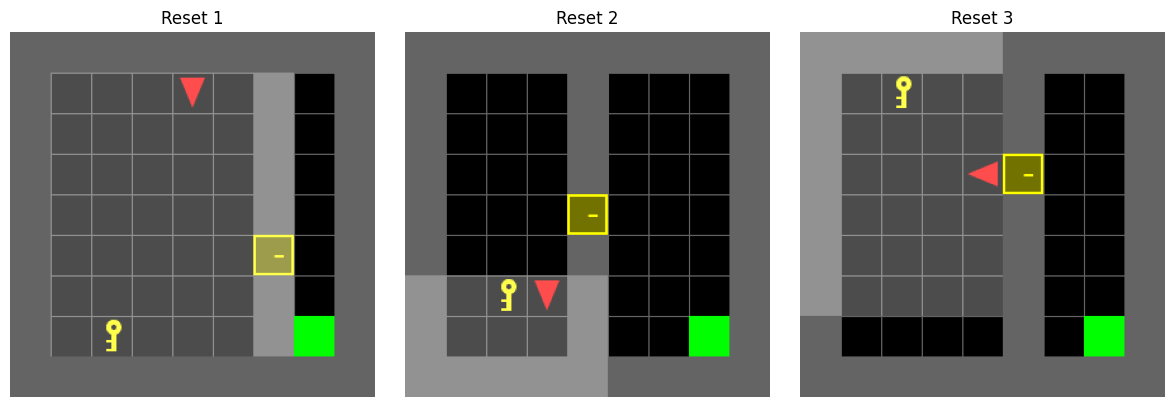

In [6]:
import gym
import minigrid
import matplotlib.pyplot as plt
import agents.learner as learner
import agents.demonstrator as demonstrator
from environments.continuous_minigrid_environment import ContinuousMinigridEnvironment
from solvers.MDP_solver_approximation import (
    MDPSolverApproximationExpectation,
    MDPSolverApproximationVariance,
)
import numpy as np
import psutil
import gc
import wandb
from random import randint
import minigrid
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


def create_minigrid_env(
    grid_size: int = 9, t: int = 25, env_name: str = "MiniGrid-DoorKey-5x5-v0"
):

    config_env = {
        "gamma": 1.0,
        "env_name": env_name,
        "render_mode": "rgb_array",
        "grid_size": grid_size,
        "seed": randint(1, 100),
        "T": 20,
    }

    env = ContinuousMinigridEnvironment(config_env)
    return env

env = create_minigrid_env()

num_checks = 3
plt.figure(figsize=(12, 4))

for i in range(num_checks):
    # 2. Reset the environment
    obs, _ = env.reset()
    print(obs.shape)
    
    # 3. Get the visual representation
    # MiniGrid usually provides a 'image' array in the obs dict
    # or you can use env.render() if you want the high-res global view
    frame = env.env.render() 
    
    plt.subplot(1, num_checks, i + 1)
    plt.imshow(frame)
    plt.title(f"Reset {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from environments.environment import ContinuousEnvironment
from policy import Policy
from stable_baselines3.common.vec_env import (
    VecFrameStack,
    VecVideoRecorder,
    VecEnvWrapper,
)
from stable_baselines3.common.atari_wrappers import WarpFrame
from stable_baselines3.common.vec_env import VecTransposeImage
from stable_baselines3.common.env_util import make_vec_env
import os
import numpy as np
import utils
from pathlib import Path
import gymnasium as gym


env_kwargs = {
            "render_mode": "rgb_array",
            "continuous": False,
            "domain_randomize": False,
            "max_episode_steps": 1000,
        }
env = make_vec_env(
    "CarRacing-v3",
    n_envs=1,
    wrapper_class=WarpFrame,
    wrapper_kwargs={"width": 84, "height": 84},
    env_kwargs=env_kwargs,
)